In [2]:
import ast
from matplotlib import pyplot as plt
import pandas as pd
df = pd.read_csv(r'C:\Users\GEORGE TECHNOLOGY EN\Documents\data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


<Axes: xlabel='job_title_short'>

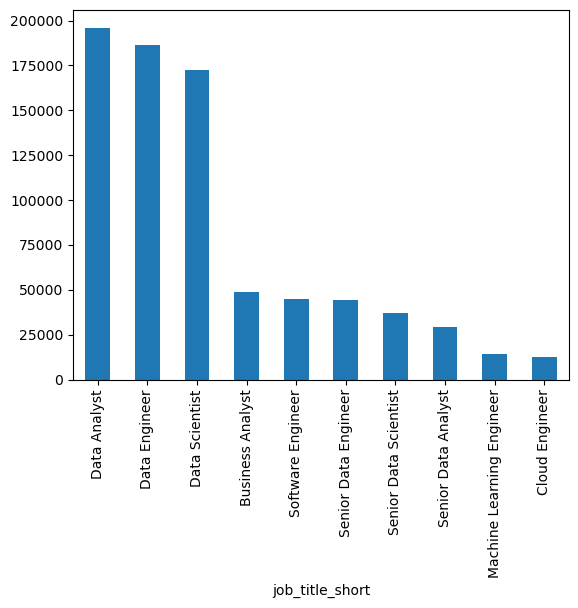

In [7]:
fig, ax = plt.subplots()
df['job_title_short'].value_counts().plot(kind='bar')

In [9]:
# ploting two plot 
df['job_schedule_type'].value_counts().head()

job_schedule_type
Full-time                  701727
Contractor                  34793
Internship                   8742
Part-time                    7881
Full-time and Part-time      6287
Name: count, dtype: int64

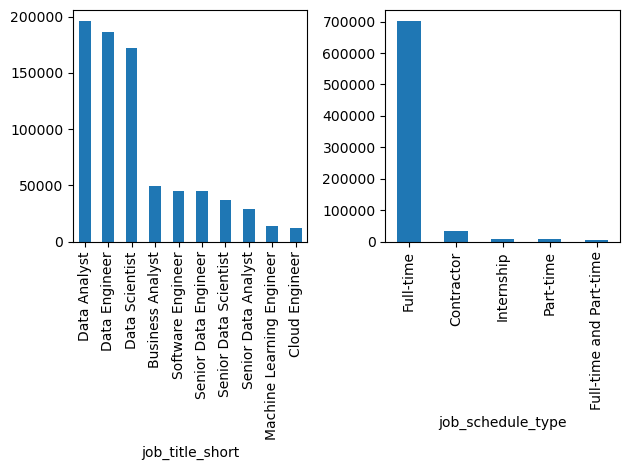

In [12]:
fig,ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head().plot(kind='bar',ax=ax[1])

fig.tight_layout()

In [23]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
1054,mattermost,Data Scientist,1
270,clickup,Machine Learning Engineer,1
797,heroku,Senior Data Analyst,1


In [22]:
job_titles = ['Data Analyst', 'Data Engineer','Data Scientist']

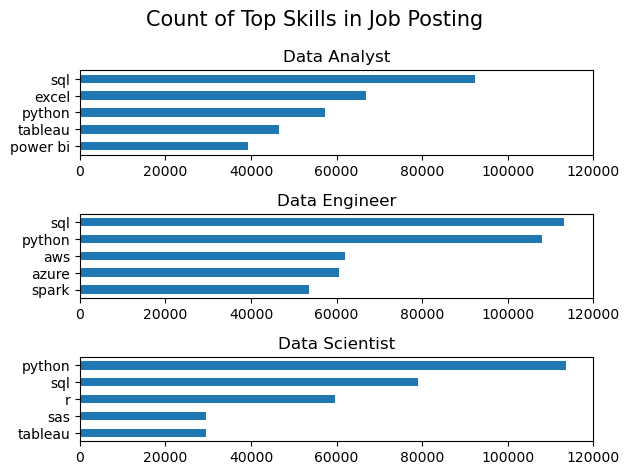

In [44]:
fig, ax = plt.subplots(3,1)

for i,job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh',x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)


fig.suptitle('Count of Top Skills in Job Posting', fontsize=15)
fig.tight_layout()